<div style="background:linear-gradient(135deg,#603813 0%,#b29f94 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🧲&nbsp; Benchmark: Active Learning vs. Random Sampling</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">Does placing collocation points intelligently beat scattering them at random? We pit a fixed-budget baseline against an active-learning trainer that adds points where the residual is largest.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">type</span><span style="background:#603813;color:#fff;padding:4px 8px;">benchmark</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">adaptive sampling</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~2 min · CPU</span></span></div>

**Hypothesis:** for the same number of optimiser steps, focusing collocation effort on hard regions
(steep fronts) yields a lower PDE residual than uniform random sampling.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#baseline" style="color:#1a73e8;text-decoration:none;">2 · Baseline: Fixed Random Collocation</a></li>
  <li style="margin:3px 0;"><a href="#active" style="color:#1a73e8;text-decoration:none;">3 · Active Learning</a></li>
  <li style="margin:3px 0;"><a href="#verdict" style="color:#1a73e8;text-decoration:none;">4 · The Verdict</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">5 · Takeaways</a></li>
  </ol>
</div>

<a id="setup"></a>

## 1 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinn").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinn version : {pinn.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinn version : 0.1.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


In [2]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)

cfg = BurgersConfig()
def make_pinn():
    torch.manual_seed(SEED); np.random.seed(SEED)
    return ContinuousPINN(MLP(2, 2, 20, 1), DEVICE, burgers_residual, cfg)

base_cfg = TrainConfig(n_u0=32, n_bc=32, n_f=512, adam_steps=600,
                       lbfgs_max_iter=0, seed=SEED, track_losses=True)

<a id="baseline"></a>

## 2 · Baseline: Fixed Random Collocation

A standard PINN with a fixed set of 512 random collocation points.

In [3]:
baseline = make_pinn()
hist_base = baseline.train(base_cfg, weights=(10.0, 1.0, 1.0))
print(f"Baseline final loss: {hist_base['total'][-1]:.3e}")

Baseline final loss: 5.868e-01


<a id="active"></a>

## 3 · Active Learning

The `ActivePINNTrainer` periodically scores a candidate pool by predictive uncertainty and adds the most informative points to the collocation set.

In [4]:
from pinnlab.sampling import (ActiveLearningConfig, ActiveLearningStrategy,
                           ActivePINNTrainer, UncertaintyAcquisition)

active = make_pinn()
strategy = ActiveLearningStrategy(UncertaintyAcquisition(mode="variance"),
                                  batch_size=4, diversity_strength=0.3)
trainer = ActivePINNTrainer(active, strategy)
acfg = ActiveLearningConfig(max_active_iterations=5, points_per_iteration=64,
                            candidate_pool_size=512, update_frequency=120,
                            convergence_tol=1e-4, patience=2)
hist_active = trainer.train_with_active_learning(base_cfg, acfg)
print(f"Active-learning final loss: {hist_active['total'][-1]:.3e}")

Active-learning final loss: 3.419e-01


<a id="verdict"></a>

## 4 · The Verdict

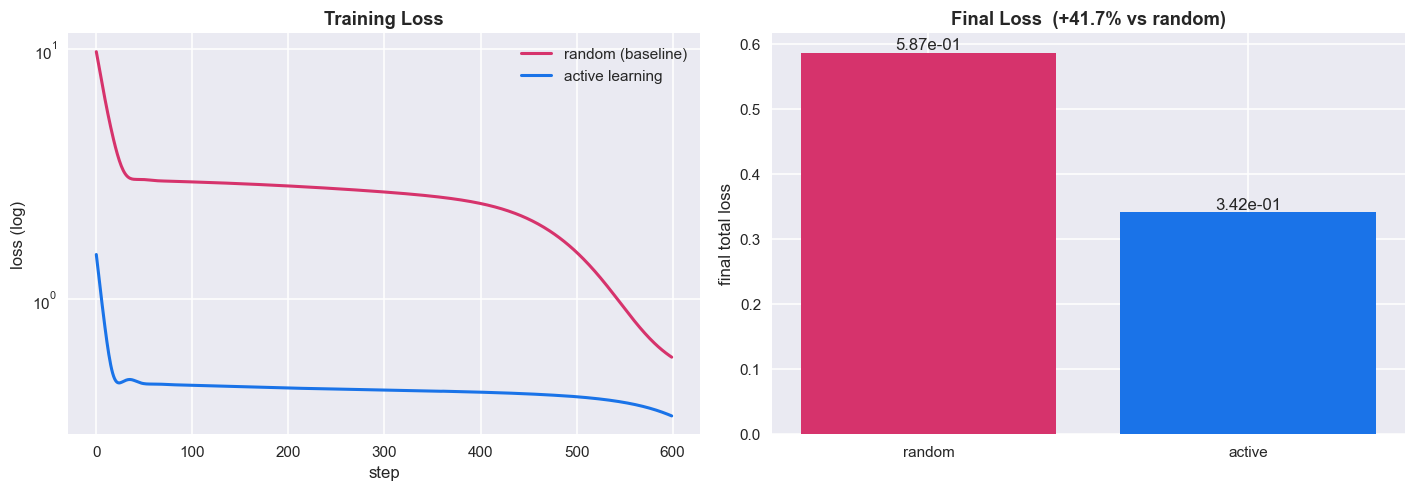

Active learning changed the final loss by +41.7% relative to random sampling.


In [5]:
b, a = hist_base["total"][-1], hist_active["total"][-1]
improve = (b - a) / b * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
ax1.plot(hist_base["total"],   color=ACCENT2, lw=2, label="random (baseline)")
ax1.plot(hist_active["total"], color=ACCENT,  lw=2, label="active learning")
ax1.set_yscale("log"); ax1.set(title="Training Loss", xlabel="step", ylabel="loss (log)"); ax1.legend()

ax2.bar(["random", "active"], [b, a], color=[ACCENT2, ACCENT])
ax2.set(title=f"Final Loss  ({improve:+.1f}% vs random)", ylabel="final total loss")
for i, v in enumerate([b, a]):
    ax2.text(i, v, f"{v:.2e}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"Active learning changed the final loss by {improve:+.1f}% relative to random sampling.")

<div style="background:#eaf2ff;border-left:5px solid #1a73e8;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>💡 Note.</b> Results vary with seed and budget — the point is the <i>workflow</i>: active learning reallocates a fixed point budget toward the hard regions instead of spending it uniformly.
</div>

<a id="takeaways"></a>

## 5 · Takeaways

- Active learning is most valuable when **collocation points are expensive** or the solution has
  **localised hard regions** (shocks, boundary layers).
- The `ActivePINNTrainer` + `UncertaintyAcquisition` combo automates the score → select → augment
  loop.
- Combine it with the importance samplers from
  [`02_sampling_and_metrics`](../02_sampling_and_metrics.ipynb) for even tighter budgets.

### 📚 References

1. Lu, L. et al. (2021). *DeepXDE*. SIAM Review, 63(1), 208–228.
2. Nabian, M. A. et al. (2021). *Efficient training of PINNs via importance sampling*. Computer-Aided Civil and Infrastructure Engineering, 36(8).

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinn</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>